In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
semeval_labels = {'AGAINST': 0, 'FAVOR': 1, 'NONE': 2}

# Load your balanced dataset (replace with your actual path)
df_balanced = pd.read_csv('balanced_data.csv')
#df_filtered = df_balanced[df_balanced['stance']==1]


0


In [13]:
df_balanced.columns

Index(['target', 'text', 'stance', 'dataset', 'word_count', 'sentence_count',
       'avg_word_length', 'std_word_length', 'type_token_ratio',
       'hapax_legomena', 'stopword_ratio', 'punctuation_density', 'noun_ratio',
       'verb_ratio', 'adj_ratio', 'adv_ratio', 'pronoun_ratio',
       'avg_dependency_depth', 'function_word_ratio', 'punctuation_usage',
       'readability_score', 'sentence_length_variation',
       'subordinate_clause_ratio', 'sentiment_polarity',
       'sentiment_subjectivity', 'anger', 'joy', 'fear', 'sadness', 'disgust',
       'surprise', 'certainty_adverbs_count', 'certainty_verbs_count',
       'certainty_adjectives_count', 'doubt_adverbs_count',
       'doubt_verbs_count', 'doubt_adjectives_count', 'hedges_score',
       'hedge_C_count', 'hedge_D_count', 'hedge_E_count', 'hedge_I_count',
       'hedge_N_count', 'C_ratio', 'D_ratio', 'E_ratio', 'I_ratio', 'N_ratio',
       'type', 'label'],
      dtype='object')

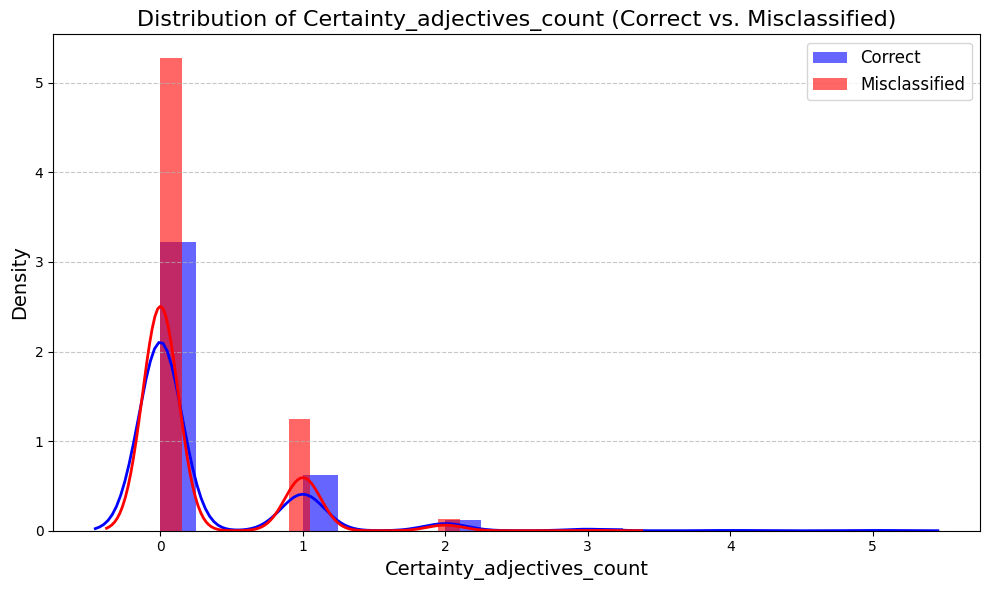

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your balanced dataset explicitly
df_balanced = pd.read_csv('balanced_data.csv')
#df_filtered = df_balanced[df_balanced['stance']==2]
# Specify the feature clearly
feature = 'certainty_adjectives_count'

# Clearly specify labels based on your actual data
correct_label = 1
misclassified_label = 0

# Drop NaNs explicitly from each subset separately
correct = df_balanced[df_balanced['label'] == correct_label][feature].dropna()
misclassified = df_balanced[df_balanced['label'] == misclassified_label][feature].dropna()

# Check if subsets have data
if correct.empty or misclassified.empty:
    raise ValueError(
        f"Data subsets issue after dropping NaNs:\n"
        f"Correct subset size: {len(correct)}\n"
        f"Misclassified subset size: {len(misclassified)}\n"
        f"Check label names or feature values explicitly."
    )

# Plot overlapping histograms
plt.figure(figsize=(10, 6))
plt.hist(correct, bins=20, alpha=0.6, color='blue', density=True, label='Correct')
plt.hist(misclassified, bins=20, alpha=0.6, color='red', density=True, label='Misclassified')

# KDE lines explicitly for smoother visualization
sns.kdeplot(correct, color='blue', linewidth=2)
sns.kdeplot(misclassified, color='red', linewidth=2)

# Titles and labels clearly defined
plt.title(f'Distribution of {feature.capitalize()} (Correct vs. Misclassified)', fontsize=16)
plt.xlabel(f'{feature.capitalize()}', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save plot
plt.savefig(f'{feature}_distribution_histogram.pdf', dpi=600, bbox_inches='tight')
plt.show()